In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

print(os.listdir("/content/drive/MyDrive"))

['taspia(232010612).pptx', 'To-do list.gsheet', '79A3D2B2-E7E7-48C9-9920-9A97D57EC85B.jpeg', 'cse lab assignmant 2.docx', 'DFF021B6-724E-40F5-A632-420E7E570F9F.jpeg', 'taspia (232010612).pdf', 'CamScanner 12-21-2023 23.17.zip', '8CC60974-75EA-4633-90B6-BC0E3BBCA520.jpeg', '6ECF0774-A121-485B-B67C-E766D56CC8E1.jpeg', 'taspia Saify  (232010612).docx', '8801866260044cdrmsisdn.xls', 'Taspia(232010612).pdf', '00540A70-4863-4DA9-9E48-38416E751595.jpeg', 'BBAB601A-7E6C-4159-A7EC-E99439A51343.jpeg', 'E16A32E1-4E86-4B30-B04B-083E73CA8486.jpeg', '25A4945B-4E3C-4301-BF14-1DB7C62DBFAC.jpeg', 'IMG_5767.PNG', '232008212 Cse124 final assignment .pdf', '740236A1-D19F-47FC-84EE-507818FDC829.jpeg', 'PHOTO-2024-02-26-11-23-54 (1).jpg', 'PHOTO-2024-02-26-11-23-56 (1).jpg', 'PHOTO-2024-02-26-11-23-51.jpg', 'PHOTO-2024-02-26-11-23-55 (1).jpg', 'PHOTO-2024-02-26-11-23-52 (2).jpg', 'PHOTO-2024-02-26-11-23-55.jpg', 'PHOTO-2024-02-26-11-23-53.jpg', 'PHOTO-2024-02-26-11-23-54.jpg', 'PHOTO-2024-02-26-11-23-52 (1)

In [4]:
import os

print(os.listdir("/content/drive/MyDrive/443"))

['bank-data.zip', 'Archive.zip']


In [5]:
import zipfile
import os

bank_zip_path = "/content/drive/MyDrive/443/bank-data.zip"

with zipfile.ZipFile(bank_zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/bank_data")

print("bank-data.zip extracted successfully!")

bank-data.zip extracted successfully!


In [6]:
print(os.listdir("/content/bank_data"))

['bank-data', '__MACOSX']


In [7]:
print(os.listdir("/content/bank_data/bank-data"))

['bank-full.csv', '.DS_Store']


In [8]:
import pandas as pd

file_path = "/content/bank_data/bank-data/bank-full.csv"

df = pd.read_csv(file_path, sep=';')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (45211, 17)


In [9]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [10]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Rows and Columns: (45211, 17)

Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [11]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [12]:
print(df['y'].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


In [13]:
df['y'] = df['y'].map({
    'no': 0,
    'yes': 1
})

print(df['y'].value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


In [14]:
df['y'] = df['y'].map({
    'no': 0,
    'yes': 1
})

print(df['y'].value_counts())

Series([], Name: count, dtype: int64)


In [15]:
X = df.drop('y', axis=1)
y = df['y']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45211, 16)
y shape: (45211,)


In [16]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Before encoding:", X.shape)
print("After encoding:", X_encoded.shape)

Before encoding: (45211, 16)
After encoding: (45211, 42)


In [17]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Before encoding:", X.shape)
print("After encoding:", X_encoded.shape)

Before encoding: (45211, 16)
After encoding: (45211, 42)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

ValueError: Input y contains NaN.

In [20]:
df['y'] = df['y'].map({'no': 0, 'yes': 1})

In [21]:
# Restore the target column correctly
df = pd.read_csv(
    "/content/bank_data/bank-data/bank-full.csv",
    sep=';'
)

df['y'] = df['y'].map({
    'no': 0,
    'yes': 1
})

X = df.drop('y', axis=1)
y = df['y']

X_encoded = pd.get_dummies(X, drop_first=True)

print("X shape:", X_encoded.shape)
print("y shape:", y.shape)
print("Missing values in y:", y.isnull().sum())

X shape: (45211, 42)
y shape: (45211,)
Missing values in y: 0


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (36168, 42)
Testing data: (9043, 42)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Feature scaling completed!
Training shape: (36168, 42)
Testing shape: (9043, 42)


In [24]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [25]:
from sklearn.metrics import accuracy_score

y_pred = model_lr.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

Test Accuracy: 0.901249585314608
Test Accuracy (%): 90.12495853146079


In [26]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['No', 'Yes']
))

              precision    recall  f1-score   support

          No       0.92      0.97      0.95      7985
         Yes       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



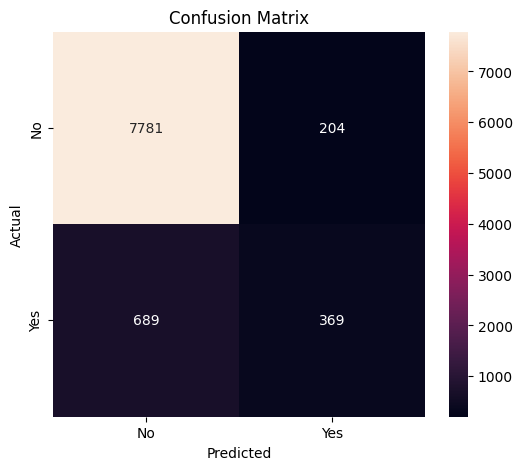

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [28]:
feature_names = X_encoded.columns

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model_lr.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print(coefficients)

                Feature  Coefficient
3              duration     1.092245
40     poutcome_success     0.421483
21   education_tertiary     0.171656
34            month_mar     0.157934
33            month_jun     0.154254
37            month_oct     0.108927
20  education_secondary     0.104355
38            month_sep     0.098016
2                   day     0.090094
11          job_retired     0.069768
29            month_dec     0.054881
39       poutcome_other     0.054157
14          job_student     0.050645
1               balance     0.046710
22    education_unknown     0.040310
19       marital_single     0.031971
6              previous     0.024724
5                 pdays     0.024723
41     poutcome_unknown     0.009974
23          default_yes    -0.010941
17          job_unknown    -0.014303
0                   age    -0.015504
26    contact_telephone    -0.028620
30            month_feb    -0.029619
16       job_unemployed    -0.032538
10       job_management    -0.057287
8

In [29]:
import joblib

joblib.dump(model_lr, '/content/logistic_regression_model.pkl')
joblib.dump(scaler, '/content/scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
